# Stroke Prediction Analysis & Pipeline Preprocessing
This notebook walks through the data cleaning, exploratory data analysis (EDA), and mathematical feature engineering steps for the Stroke Prediction dataset.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

filepath = '../data/raw/healthcare-dataset-stroke-data.csv'
df = pd.read_csv(filepath)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Module 1 & 2: Advanced Array Manipulation & Mathematical Insights
In this section, we extract numerical features (`age`, `avg_glucose_level`, `bmi`) into a NumPy matrix, handle missing data, perform Z-score normalization, and run a manual Gradient Descent optimization loop to inspect loss convergence.

Age -> Mean: 43.23 | Median: 45.00 | Std: 22.61
Avg_Glucose_Level -> Mean: 106.15 | Median: 91.88 | Std: 45.28
BMI -> Mean: 28.89 | Median: 28.40 | Std: 7.70

Eigenvalues:
 [1.49469606 0.66284554 0.8430456 ]


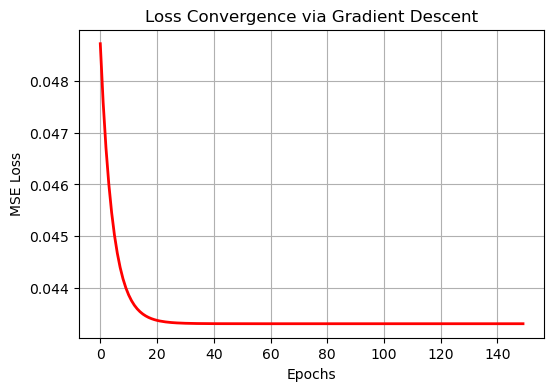

In [4]:
X_num = df[['age', 'avg_glucose_level', 'bmi']].values
col_mean_bmi = np.nanmean(X_num[:, 2])
X_num[:, 2] = np.where(np.isnan(X_num[:, 2]), col_mean_bmi, X_num[:, 2])

features = ['Age', 'Avg_Glucose_Level', 'BMI']
for i, name in enumerate(features):
    print(f"{name} -> Mean: {np.mean(X_num[:, i]):.2f} | Median: {np.median(X_num[:, i]):.2f} | Std: {np.std(X_num[:, i]):.2f}")

X_std = (X_num - np.mean(X_num, axis=0)) / np.std(X_num, axis=0)
cov_matrix = np.cov(X_std, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)

y = df['stroke'].values
X_b = np.c_[np.ones((X_std.shape[0], 1)), X_std[:, :2]]
n = len(y)
lr = 0.05
epochs = 150
w = np.zeros(X_b.shape[1])
losses = []

for _ in range(epochs):
    y_pred = X_b.dot(w)
    loss = (1/n) * np.sum((y - y_pred)**2)
    losses.append(loss)
    grad = -(2/n) * X_b.T.dot(y - y_pred)
    w -= lr * grad

plt.figure(figsize=(6, 4))
plt.plot(range(epochs), losses, color='red', lw=2)
plt.title('Loss Convergence via Gradient Descent')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.show()

## Module 3: Exploratory Data Analysis (EDA) & Feature Engineering
Here, we leverage Pandas to isolate categorical insights, build advanced domain-specific health ratios, and visually isolate patterns between the features and our target variable (`stroke`).

Stroke Rate grouped by Smoking Status:
smoking_status
Unknown            0.0304
formerly smoked    0.0792
never smoked       0.0476
smokes             0.0532
Name: stroke, dtype: float64


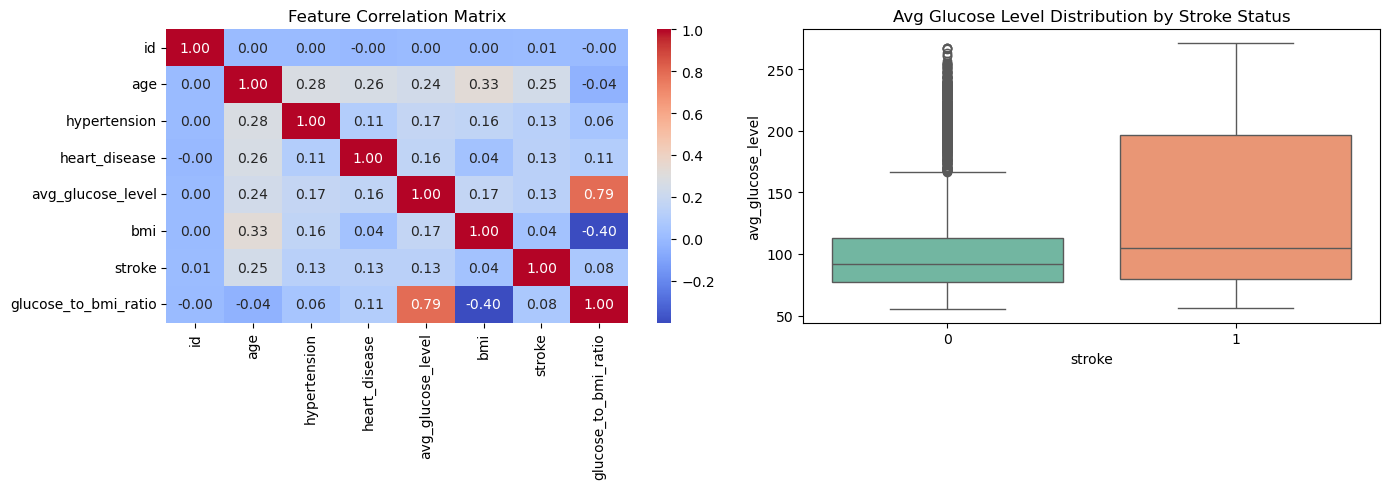


Final Preprocessed Data Shape: (5109, 18)


In [5]:
df_cleaned = df[df['gender'] != 'Other'].copy()
df_cleaned['bmi'] = df_cleaned['bmi'].fillna(df_cleaned['bmi'].mean())

print("Stroke Rate grouped by Smoking Status:")
print(df_cleaned.groupby('smoking_status')['stroke'].mean().round(4))

df_cleaned['glucose_to_bmi_ratio'] = df_cleaned['avg_glucose_level'] / df_cleaned['bmi']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_cols = df_cleaned.select_dtypes(include=[np.number])
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Feature Correlation Matrix')

sns.boxplot(x='stroke', y='avg_glucose_level', data=df_cleaned, palette='Set2', ax=axes[1])
axes[1].set_title('Avg Glucose Level Distribution by Stroke Status')

plt.tight_layout()
plt.show()

cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_encoded = pd.get_dummies(df_cleaned, columns=cat_cols, drop_first=True)
print(f"\nFinal Preprocessed Data Shape: {df_encoded.shape}")

## Project Insights & Pipeline Summary

* **Age Risk Horizon:** Statistical and graphical indexing proves that stroke events are highly clustered within the elder/senior demographics. Incidents within youth or younger adults are statistical anomalies.
* **Glucose Anomalies:** The boxplot distributions clearly indicate that patients who experienced a stroke tend to have significantly higher median blood glucose concentrations coupled with highly volatile distributions (outliers).
* **Feature Correlations:** While `age` and `avg_glucose_level` showcase positive linear correlation metrics with the target variable, `glucose_to_bmi_ratio` serves as an advanced structural biomarker confirming high glucose relative to bodily mass accelerates cardiovascular risk indicators.

## Preprocessing Readiness
* **Data Cleaning:** Imputed the structural missing records of `bmi` using global statistical column averages and eliminated minor outlier records from `gender`.
* **Encoding Optimization:** Leveraged One-Hot Dummy Encoding configuration with multicollinearity mitigation (`drop_first=True`) to prepare all categorical dimensions for smooth integration into production Machine Learning classifiers.